In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression 
from sklearn.metrics import classification_report
from sklearn.tree import DecisionTreeClassifier

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import metrics
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
import numpy as np

In [5]:
df = pd.read_csv('diabetes.csv')
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='str')

In [6]:
df.sample(10)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
556,1,97,70,40,0,38.1,0.218,30,0
248,9,124,70,33,402,35.4,0.282,34,0
358,12,88,74,40,54,35.3,0.378,48,0
340,1,130,70,13,105,25.9,0.472,22,0
406,4,115,72,0,0,28.9,0.376,46,1
393,4,116,72,12,87,22.1,0.463,37,0
295,6,151,62,31,120,35.5,0.692,28,0
44,7,159,64,0,0,27.4,0.294,40,0
404,5,168,64,0,0,32.9,0.135,41,1
526,1,97,64,19,82,18.2,0.299,21,0


In [7]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [8]:
cols = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']
df[cols] = df[cols].replace(0,np.nan)

In [9]:
# Valeurs manquantes
df.isnull().sum()

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

In [10]:
# The values to be given for incomplete observations are given the median value of people who are not sick 
# and the median values of people who are sick.
columns = df.columns
columns = columns.drop("Outcome")
for col in columns:
    median = df[col].median()
    df[col]=df[col].fillna(median)

In [11]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.656250,72.386719,29.108073,140.671875,32.455208,0.471876,33.240885,0.348958
std,3.369578,30.438286,12.096642,8.791221,86.383060,6.875177,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,121.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,29.000000,125.000000,32.300000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [12]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

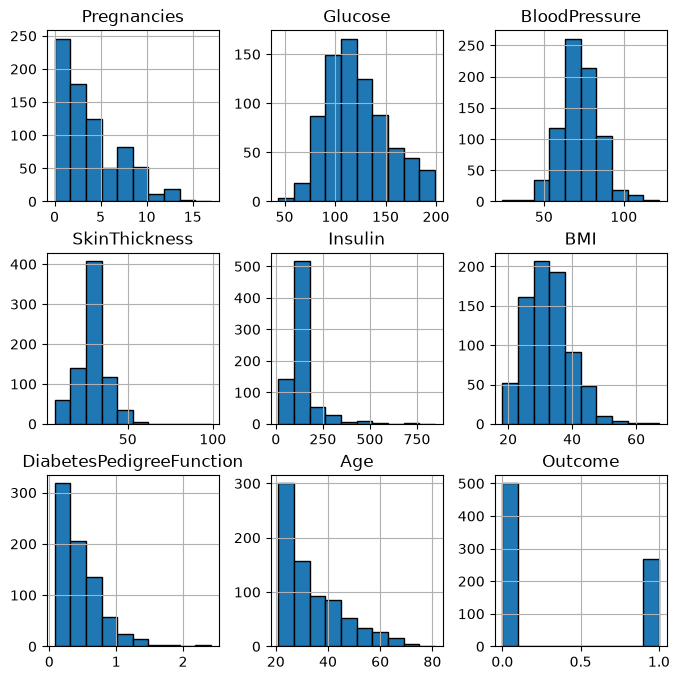

In [13]:
# Creating histograms
df.hist(figsize=(8,8), edgecolor = "black")
plt.show()

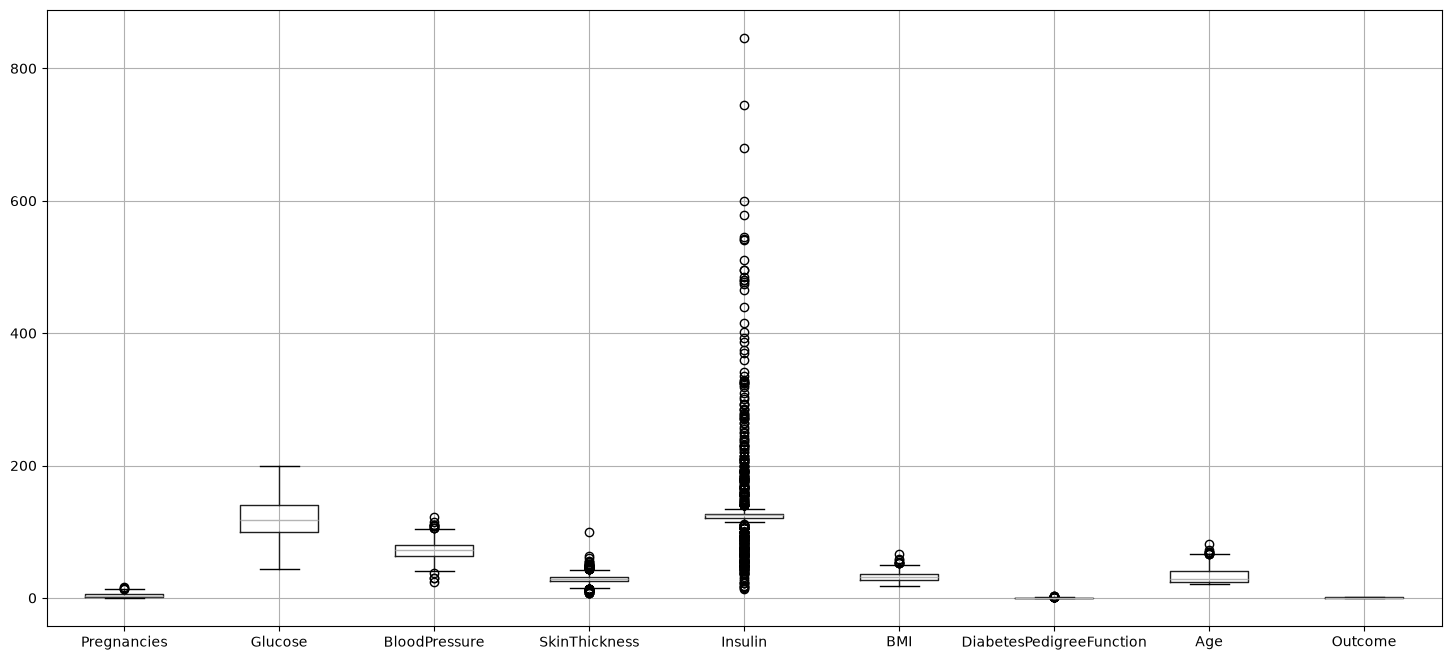

In [14]:
df.boxplot(figsize=(18,8))
#plt.figure(figsize=(18,10))
#sns.boxplot(df, orient='h')
plt.show()

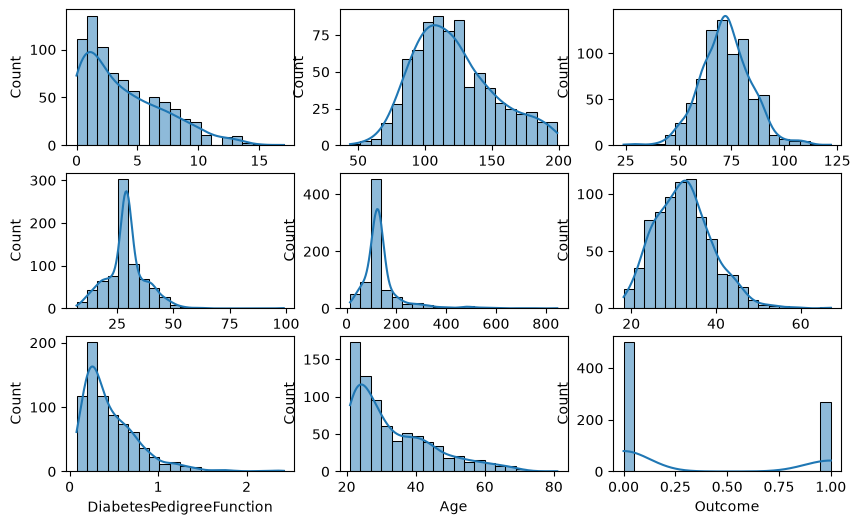

In [15]:
cols = df.columns
fig, ax = plt.subplots(3,3, figsize=(10,6))
row_index = 0
col_index = 0
for col in cols :
    sns.histplot(df[col], bins = 20, ax=ax[row_index,col_index],kde=True) 
    col_index = col_index +1
    if(col_index ==3):
        col_index=0
        row_index = row_index +1

In [16]:
df["Outcome"].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

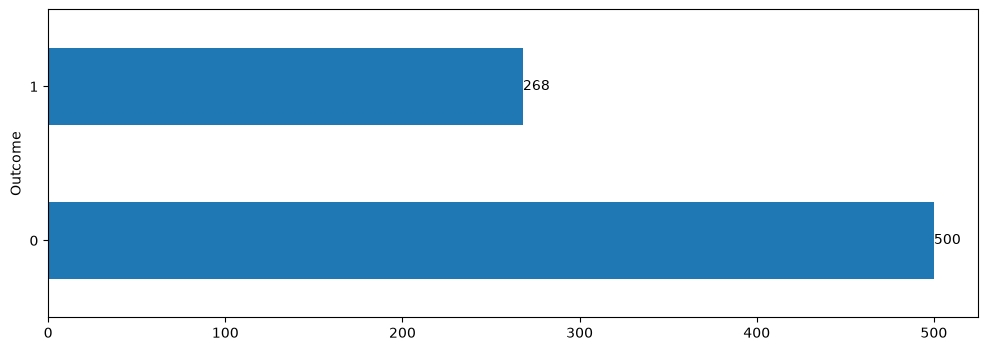

In [17]:
bar=df['Outcome'].value_counts().plot.barh(figsize=(12,4))
bar=bar.bar_label(bar.containers[0], fontsize=10)

In [18]:
pd.crosstab(df['Age'],df['Outcome'], normalize='index')*100

Outcome,0,1
Age,,
21,92.063492,7.936508
22,84.722222,15.277778
23,81.578947,18.421053
24,82.608696,17.391304
25,70.833333,29.166667
26,75.757576,24.242424
27,75.000000,25.000000
28,71.428571,28.571429
29,55.172414,44.827586


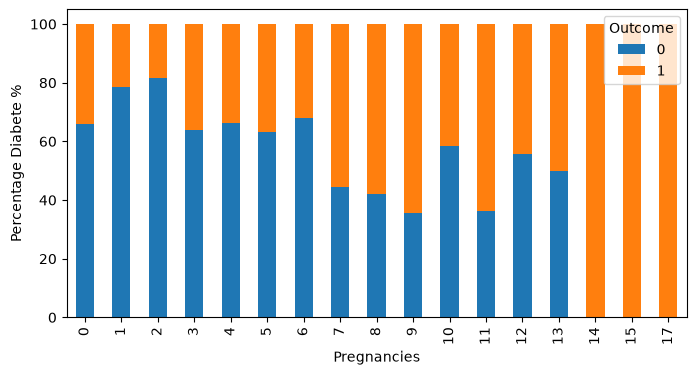

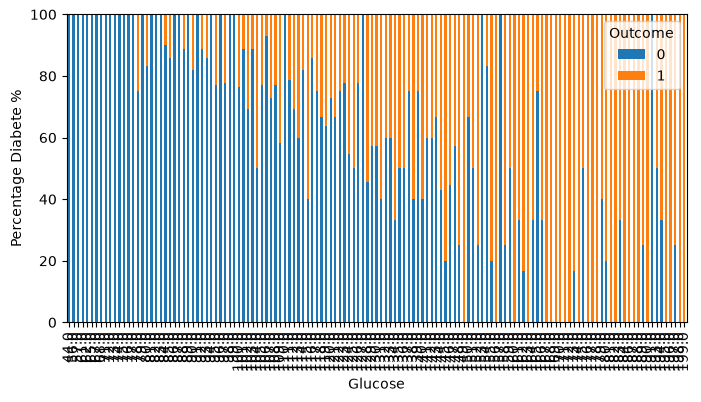

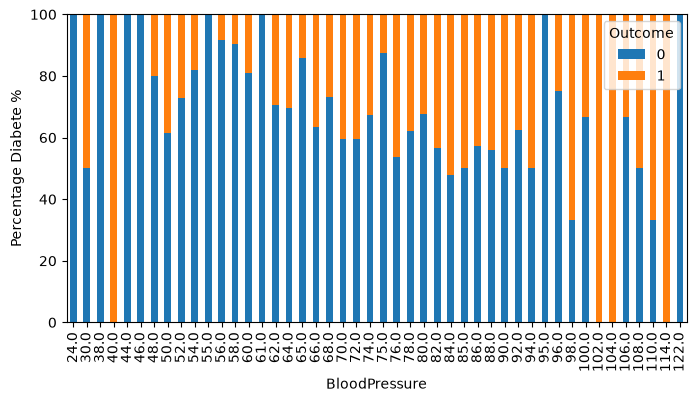

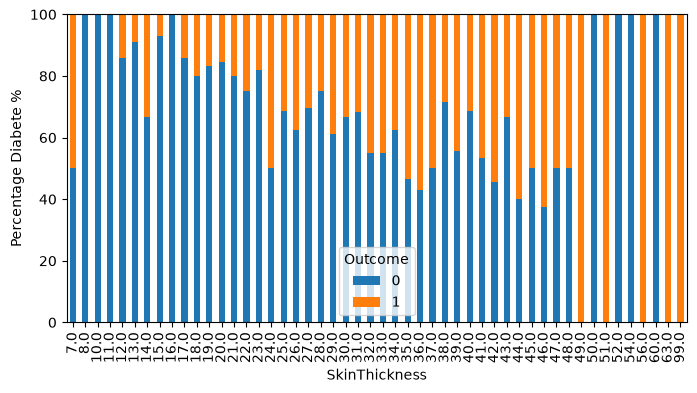

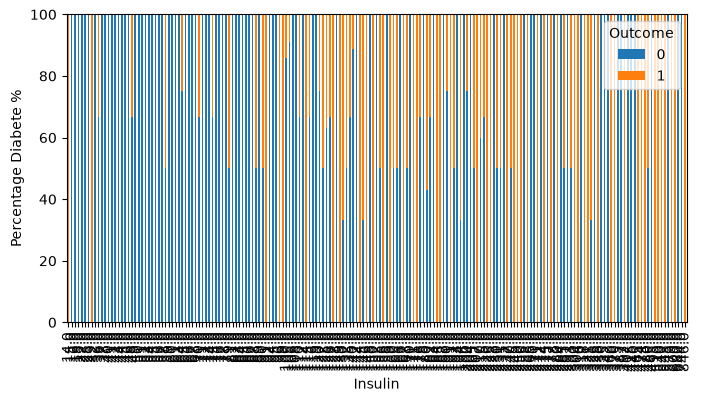

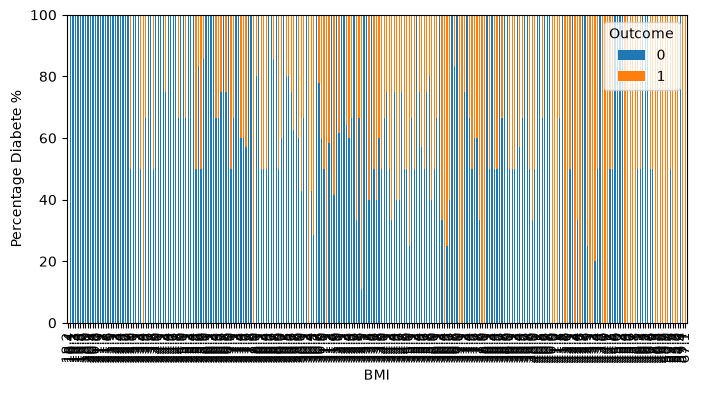

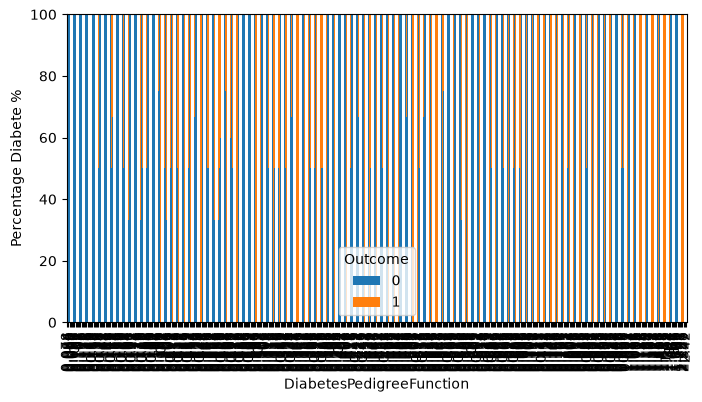

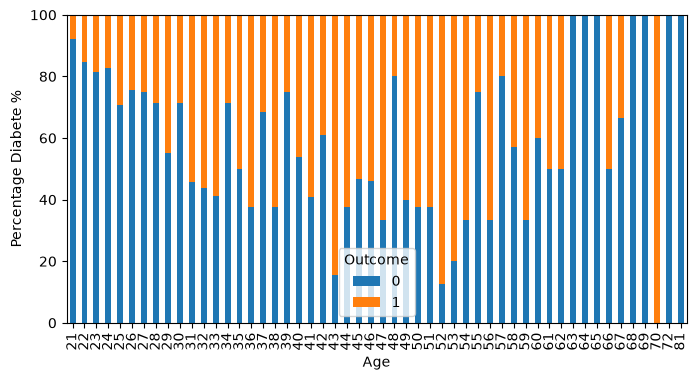

In [19]:
for i in df.columns:
    if i!='Outcome':
        (pd.crosstab(
            df[i],df['Outcome'],normalize='index')*100).plot(
            kind='bar',
            figsize=(8,4),stacked=True)
        plt.ylabel('Percentage Diabete %')

In [20]:
df.groupby(['Outcome'])[df.columns].mean()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Outcome,,,,,,,,,
0,3.298000,110.682000,70.920000,27.726000,127.792000,30.885600,0.429734,31.190000,0.0
1,4.865672,142.130597,75.123134,31.686567,164.701493,35.383582,0.550500,37.067164,1.0


<Axes: xlabel='Outcome'>

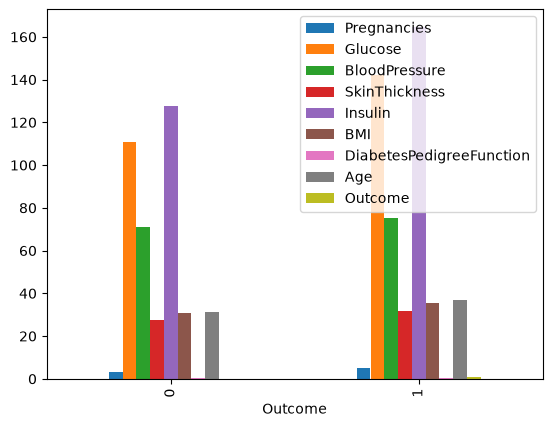

In [21]:
df.groupby(['Outcome'])[df.columns].mean().plot.bar()

In [22]:
y = df['Outcome']
X= df.drop(columns=['Outcome'])

<Axes: >

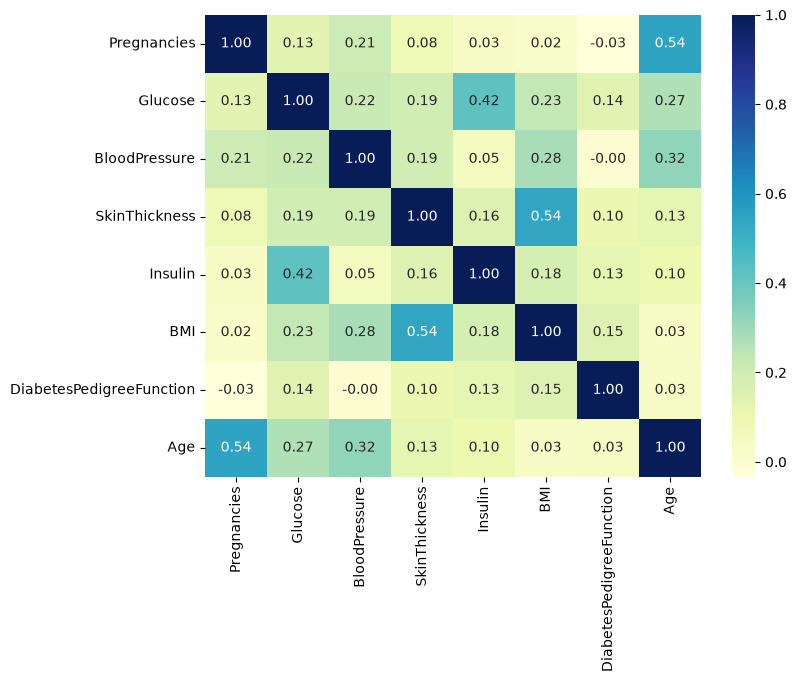

In [23]:
# Plotting the correlation between numerical variables
plt.figure(figsize=(8,6))
sns.heatmap(X.corr(),annot=True, fmt='0.2f', cmap='YlGnBu')

In [24]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=123)

In [25]:
# Scaling the data
sc=StandardScaler()

# Fit_transform on train data
X_train_scaled=sc.fit_transform(X_train)
X_train_scaled=pd.DataFrame(X_train_scaled, columns=X.columns)

# Transform on test data
X_test_scaled=sc.transform(X_test)
X_test_scaled=pd.DataFrame(X_test_scaled, columns=X.columns)

In [26]:
X_train.head(5)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
429,1,95.0,82.0,25.0,180.0,35.0,0.233,43
524,3,125.0,58.0,29.0,125.0,31.6,0.151,24
212,7,179.0,95.0,31.0,125.0,34.2,0.164,60
558,11,103.0,68.0,40.0,125.0,46.2,0.126,42
66,0,109.0,88.0,30.0,125.0,32.5,0.855,38


In [27]:
X_train_scaled.head(5)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,-0.847578,-0.854765,0.814151,-0.493730,0.435780,0.377880,-0.695485,0.815489
1,-0.244332,0.131856,-1.206800,-0.015151,-0.195233,-0.126494,-0.943389,-0.789224
2,0.962161,1.907772,1.908833,0.224139,-0.195233,0.259203,-0.904087,2.251285
3,2.168653,-0.591666,-0.364737,1.300943,-0.195233,2.039345,-1.018969,0.731031
4,-1.149201,-0.394342,1.319389,0.104494,-0.195233,0.007017,1.184953,0.393196


In [28]:
model_lgr = LogisticRegression(max_iter=1000)
model_lgr.fit(X_train_scaled,y_train)
y_pred_train = model_lgr.predict(X_train_scaled)
y_pred_test = model_lgr.predict(X_test_scaled)

In [29]:
print("Accuracy",metrics.accuracy_score(y_train, y_pred_train))
print("Precision",metrics.precision_score(y_train, y_pred_train))
print("Recall",metrics.recall_score(y_train, y_pred_train))

Accuracy 0.7672253258845437
Precision 0.7099236641221374
Recall 0.5166666666666667


In [30]:
print(classification_report(y_train, y_pred_train))

              precision    recall  f1-score   support

           0       0.79      0.89      0.84       357
           1       0.71      0.52      0.60       180

    accuracy                           0.77       537
   macro avg       0.75      0.71      0.72       537
weighted avg       0.76      0.77      0.76       537



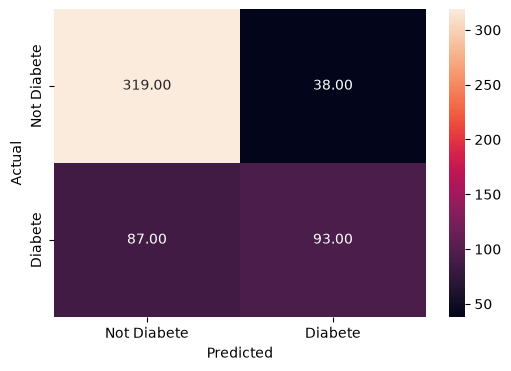

In [31]:
cm = metrics.confusion_matrix(y_train, y_pred_train)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True,  fmt='.2f', xticklabels=['Not Diabete', 'Diabete'], yticklabels=['Not Diabete', 'Diabete'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()


In [32]:
print(classification_report(y_test, y_pred_test))

              precision    recall  f1-score   support

           0       0.79      0.90      0.84       143
           1       0.78      0.60      0.68        88

    accuracy                           0.78       231
   macro avg       0.78      0.75      0.76       231
weighted avg       0.78      0.78      0.78       231



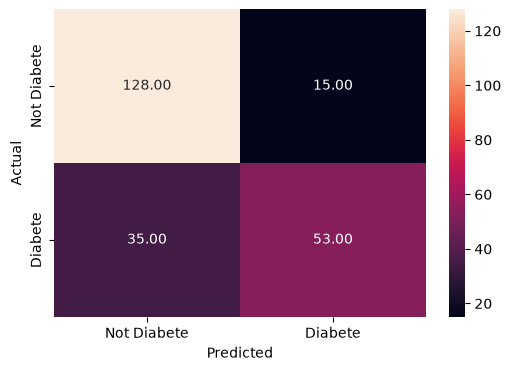

In [33]:
cm = metrics.confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True,  fmt='.2f', xticklabels=['Not Diabete', 'Diabete'], yticklabels=['Not Diabete', 'Diabete'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [34]:
# Creating metric function 
def metrics_score(actual, predicted):
    print(classification_report(actual, predicted))
    cm = metrics.confusion_matrix(actual, predicted)
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True,  fmt='.2f', xticklabels=['Not Diabete', 'Diabete'], yticklabels=['Not Diabete', 'Diabete'])
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

              precision    recall  f1-score   support

           0       0.79      0.89      0.84       357
           1       0.71      0.52      0.60       180

    accuracy                           0.77       537
   macro avg       0.75      0.71      0.72       537
weighted avg       0.76      0.77      0.76       537



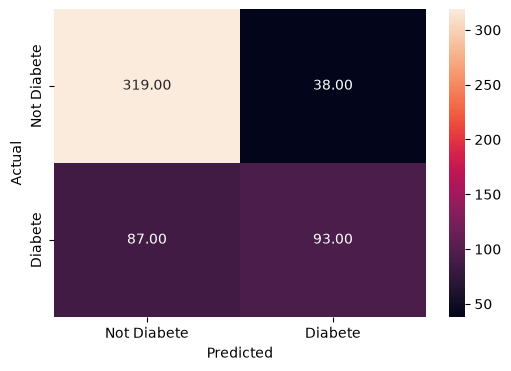

In [35]:
metrics_score(y_train, y_pred_train)

              precision    recall  f1-score   support

           0       0.79      0.90      0.84       143
           1       0.78      0.60      0.68        88

    accuracy                           0.78       231
   macro avg       0.78      0.75      0.76       231
weighted avg       0.78      0.78      0.78       231



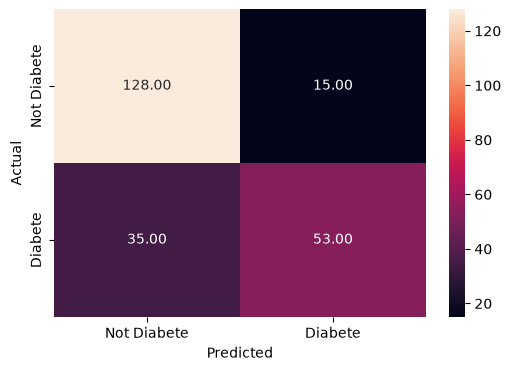

In [36]:
metrics_score(y_test, y_pred_test)

In [37]:
# Printing the coefficients of logistic regression
cols=X.columns
coef_lg=model_lgr.coef_
coefs=pd.DataFrame(coef_lg,columns=cols).T.sort_values(by = 0,ascending = False)
coefs

,0
Glucose,1.085682
BMI,0.628917
Pregnancies,0.387982
DiabetesPedigreeFunction,0.256931
Age,0.134037
SkinThickness,0.008910
BloodPressure,-0.125143
Insulin,-0.184905


<Axes: >

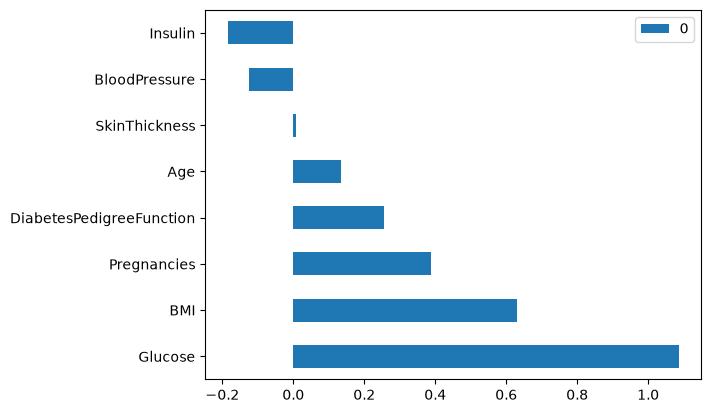

In [38]:
coefs.plot.barh()

In [39]:
import numpy as np
# Finding the odds
odds = np.exp(model_lgr.coef_[0]) 

# Adding the odds to a dataframe and sorting the values
df_odds=pd.DataFrame(odds, X_train_scaled.columns, columns = ['odds']).sort_values(by ='odds', ascending = True) 
df_odds

,odds
Insulin,0.831183
BloodPressure,0.882371
SkinThickness,1.008950
Age,1.143435
DiabetesPedigreeFunction,1.292956
Pregnancies,1.474003
BMI,1.875578
Glucose,2.961460


<Axes: >

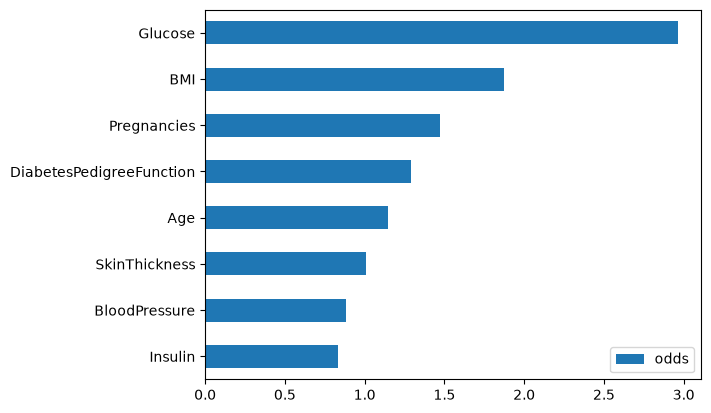

In [40]:
df_odds.plot.barh()

In [41]:
y_scores_lg=model_lgr.predict_proba(X_train_scaled)
y_scores_lg

array([[0.89798657, 0.10201343],
       [0.74875639, 0.25124361],
       [0.17127307, 0.82872693],
       ...,
       [0.88653322, 0.11346678],
       [0.749124  , 0.250876  ],
       [0.81197394, 0.18802606]], shape=(537, 2))

In [42]:
y_scores_lg=model_lgr.predict_proba(X_train_scaled)
precisions_lg, recalls_lg, thresholds_lg = metrics.precision_recall_curve(y_train, y_scores_lg[:,1])
precisions_lg

array([0.33519553, 0.3358209 , 0.3364486 , 0.33707865, 0.33771107,
       0.33834586, 0.33898305, 0.33962264, 0.34026465, 0.34090909,
       0.34155598, 0.34220532, 0.34285714, 0.34351145, 0.34416826,
       0.34482759, 0.34548944, 0.34615385, 0.34682081, 0.34749035,
       0.34816248, 0.34883721, 0.34951456, 0.35019455, 0.35087719,
       0.3515625 , 0.35225049, 0.35294118, 0.35363458, 0.35433071,
       0.35502959, 0.35573123, 0.35643564, 0.35714286, 0.35785288,
       0.35856574, 0.35928144, 0.36      , 0.36072144, 0.36144578,
       0.36217304, 0.36290323, 0.36363636, 0.36437247, 0.36511156,
       0.36585366, 0.36659878, 0.36734694, 0.36809816, 0.36885246,
       0.36960986, 0.37037037, 0.37113402, 0.37190083, 0.37267081,
       0.37344398, 0.37214137, 0.37291667, 0.3736952 , 0.37447699,
       0.37526205, 0.37605042, 0.37684211, 0.37763713, 0.37843552,
       0.37923729, 0.38004246, 0.38085106, 0.38166311, 0.38247863,
       0.38329764, 0.38412017, 0.38494624, 0.38577586, 0.38660

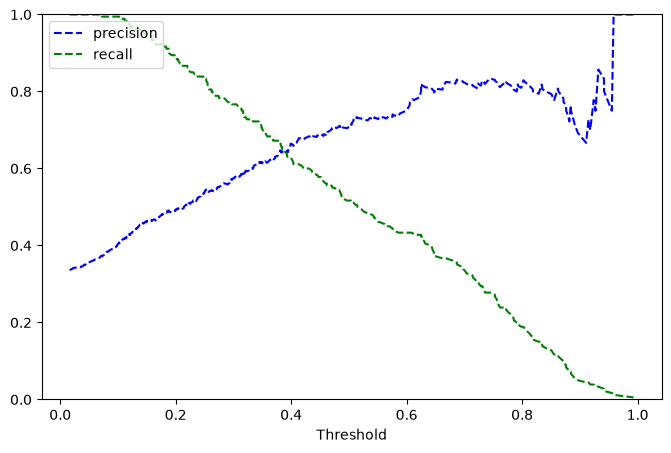

In [43]:
# Predict_proba gives the probability of each observation belonging to each class
y_scores_lg=model_lgr.predict_proba(X_train_scaled)
precisions_lg, recalls_lg, thresholds_lg = metrics.precision_recall_curve(y_train, y_scores_lg[:,1])
# Plot values of precisions, recalls, and thresholds
plt.figure(figsize=(8,5))
plt.plot(thresholds_lg, precisions_lg[:-1], 'b--', label='precision')
plt.plot(thresholds_lg, recalls_lg[:-1], 'g--', label = 'recall')
plt.xlabel('Threshold')
plt.legend(loc='upper left')
plt.ylim([0,1])
plt.show()

              precision    recall  f1-score   support

           0       0.82      0.84      0.83       357
           1       0.66      0.62      0.64       180

    accuracy                           0.77       537
   macro avg       0.74      0.73      0.73       537
weighted avg       0.76      0.77      0.77       537



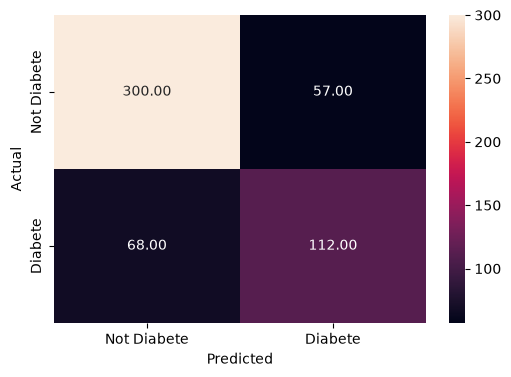

In [44]:
optimal_threshold=.4
y_pred_train = model_lgr.predict_proba(X_train_scaled)
metrics_score(y_train, y_pred_train[:,1]>optimal_threshold)

              precision    recall  f1-score   support

           0       0.82      0.84      0.83       143
           1       0.73      0.70      0.72        88

    accuracy                           0.79       231
   macro avg       0.78      0.77      0.77       231
weighted avg       0.79      0.79      0.79       231



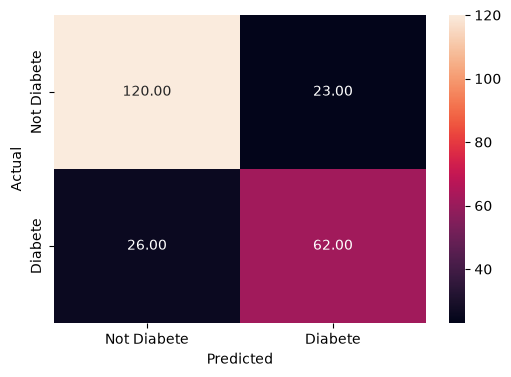

In [45]:
optimal_threshold=.4
y_pred_test = model_lgr.predict_proba(X_test_scaled)
metrics_score(y_test, y_pred_test[:,1]>optimal_threshold)

              precision    recall  f1-score   support

           0       0.77      0.89      0.83       357
           1       0.70      0.48      0.57       180

    accuracy                           0.76       537
   macro avg       0.74      0.69      0.70       537
weighted avg       0.75      0.76      0.74       537



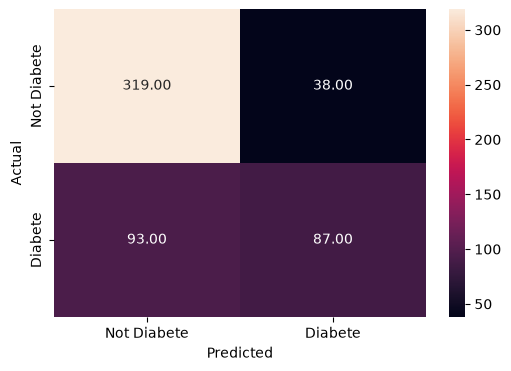

In [46]:
# Fitting SVM
model2 = SVC(kernel='linear') # Linear kernal or linear decision boundary
model2.fit(X_train_scaled, y_train)
pred_train=model2.predict(X_train_scaled)
pred_test = model2.predict(X_test_scaled)
metrics_score(y_train, pred_train)

              precision    recall  f1-score   support

           0       0.80      0.90      0.85       143
           1       0.80      0.62      0.70        88

    accuracy                           0.80       231
   macro avg       0.80      0.76      0.77       231
weighted avg       0.80      0.80      0.79       231



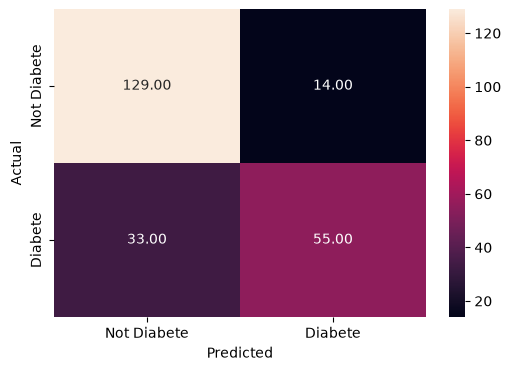

In [47]:
metrics_score(y_test, pred_test)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       357
           1       1.00      1.00      1.00       180

    accuracy                           1.00       537
   macro avg       1.00      1.00      1.00       537
weighted avg       1.00      1.00      1.00       537



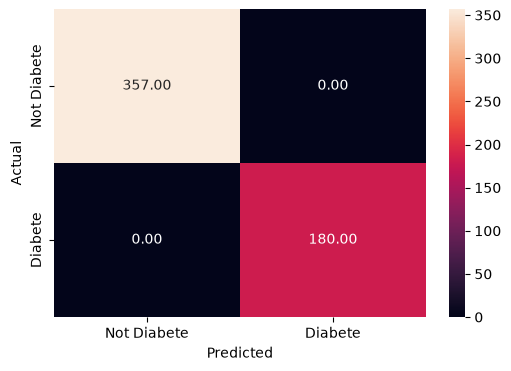

In [48]:
# Building decision tree model
model3 = DecisionTreeClassifier(class_weight = {0: 0.17, 1: 0.83}, random_state = 1)
model3.fit(X_train_scaled, y_train)
pred_train=model3.predict(X_train_scaled)
pred_test = model3.predict(X_test_scaled)
metrics_score(y_train, pred_train)

              precision    recall  f1-score   support

           0       0.77      0.76      0.76       143
           1       0.61      0.62      0.62        88

    accuracy                           0.71       231
   macro avg       0.69      0.69      0.69       231
weighted avg       0.71      0.71      0.71       231



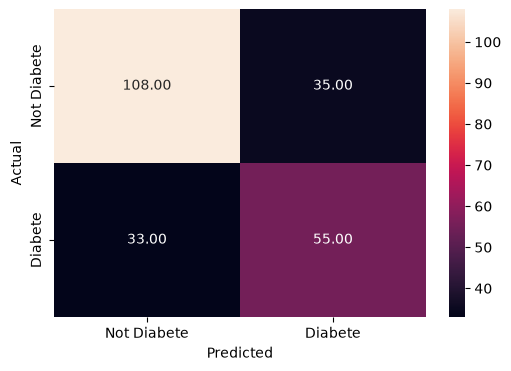

In [49]:
metrics_score(y_test, pred_test)

In [50]:
# Plot the feature importance

importances = model3.feature_importances_
columns = X.columns
importance_df = pd.DataFrame(importances, index = columns, columns = ['Importance']).sort_values(by = 'Importance', ascending = False)
importance_df

,Importance
Glucose,0.304682
BMI,0.215255
Age,0.126000
DiabetesPedigreeFunction,0.107124
Insulin,0.082967
BloodPressure,0.072890
SkinThickness,0.063437
Pregnancies,0.027644


In [51]:
importance_df=importance_df.reset_index()
importance_df

,index,Importance
0,Glucose,0.304682
1,BMI,0.215255
2,Age,0.126000
3,DiabetesPedigreeFunction,0.107124
4,Insulin,0.082967
5,BloodPressure,0.072890
6,SkinThickness,0.063437
7,Pregnancies,0.027644


<Axes: xlabel='Importance', ylabel='index'>

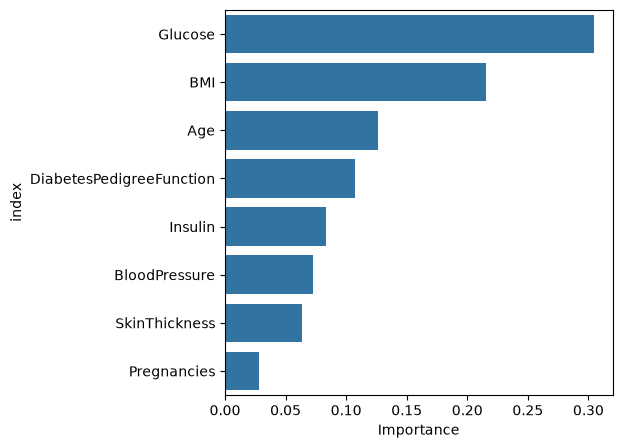

In [52]:
plt.figure(figsize = (5, 5))
sns.barplot(data=importance_df, y='index',x='Importance', orient='h')

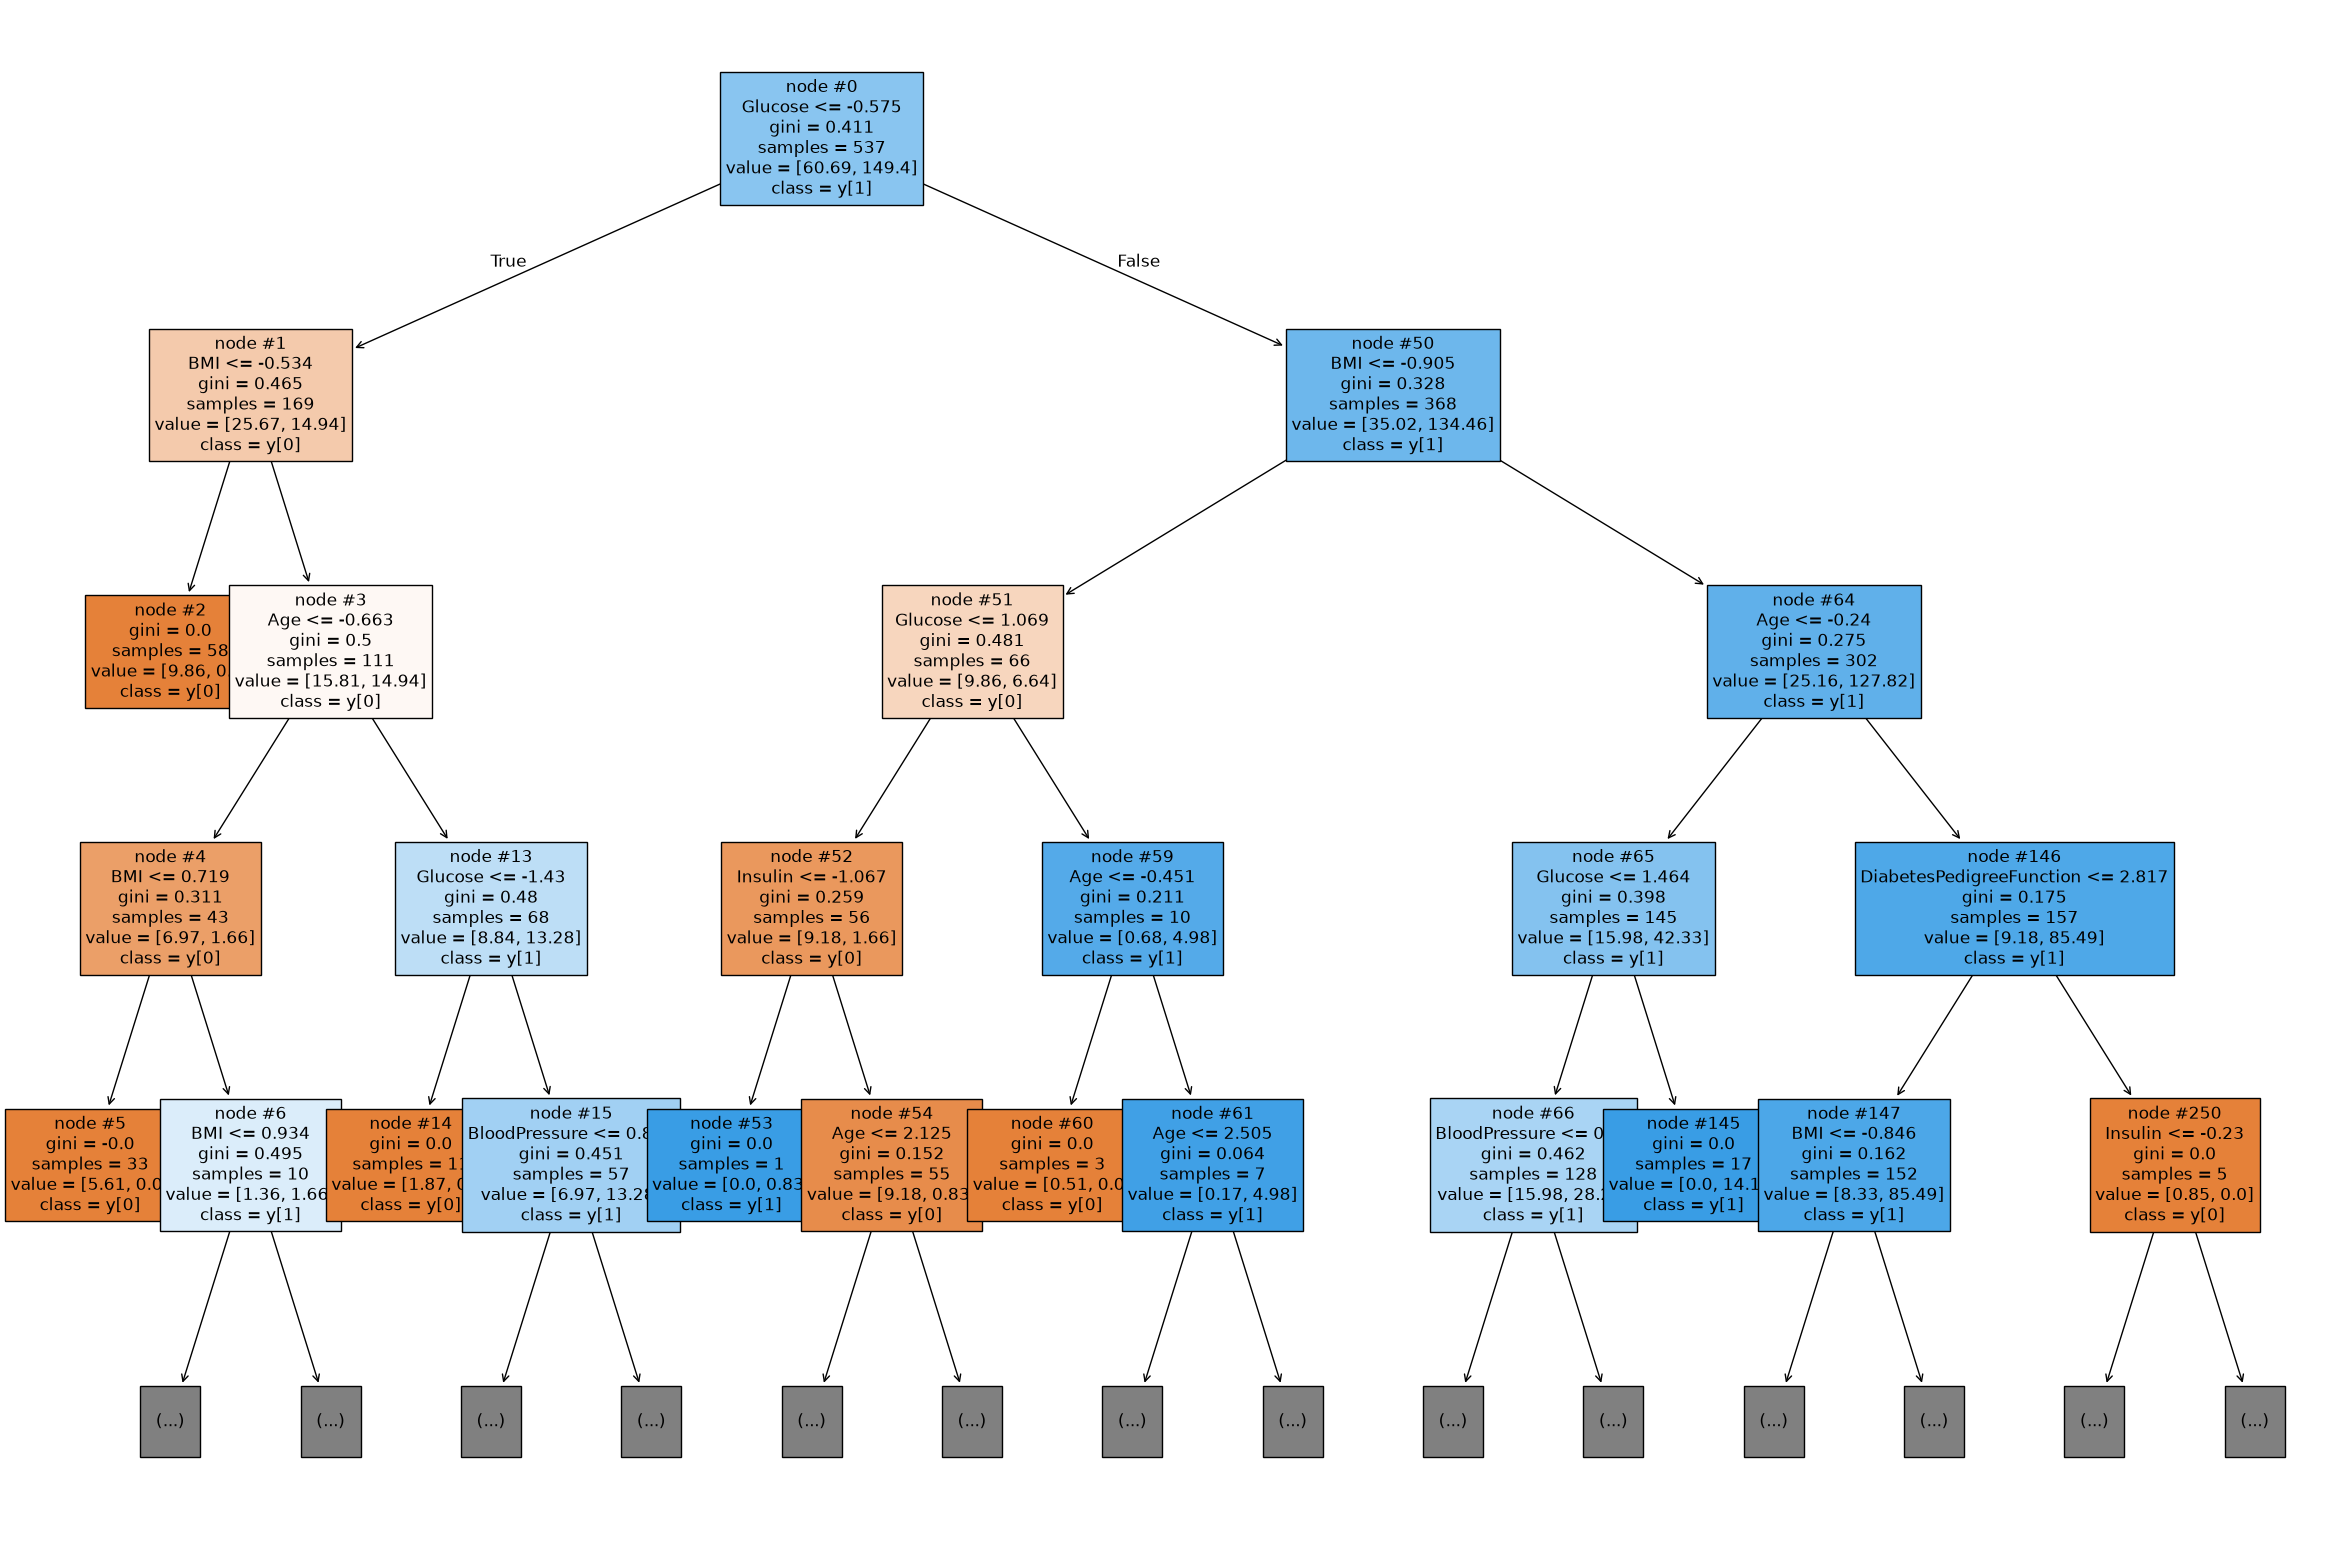

In [53]:
from sklearn import tree
features = list(X.columns)
plt.figure(figsize = (30, 20))
tree.plot_tree(model3, max_depth = 4, feature_names = features, filled = True, fontsize = 12, node_ids = True, class_names = True)

plt.show()

In [54]:
from sklearn.neural_network import MLPClassifier
model4 = MLPClassifier(solver='lbfgs', alpha=1e-5,
                    hidden_layer_sizes=(10,5,3), random_state=1, max_iter=2000)
model4.fit(X= X_train_scaled, y = y_train)

pred_train=model4.predict(X_train_scaled)
pred_test = model4.predict(X_test_scaled)

              precision    recall  f1-score   support

           0       0.92      0.97      0.94       357
           1       0.93      0.82      0.87       180

    accuracy                           0.92       537
   macro avg       0.92      0.90      0.91       537
weighted avg       0.92      0.92      0.92       537



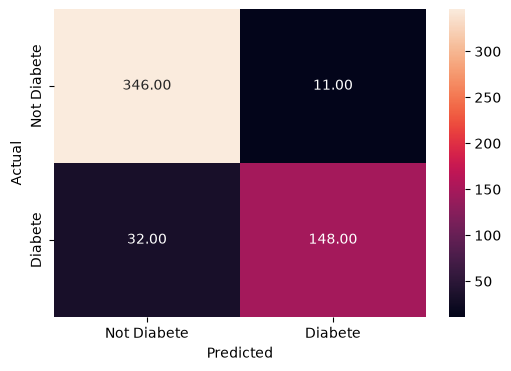

In [55]:
metrics_score(y_train, pred_train)

              precision    recall  f1-score   support

           0       0.78      0.84      0.81       143
           1       0.71      0.62      0.66        88

    accuracy                           0.76       231
   macro avg       0.74      0.73      0.74       231
weighted avg       0.75      0.76      0.75       231



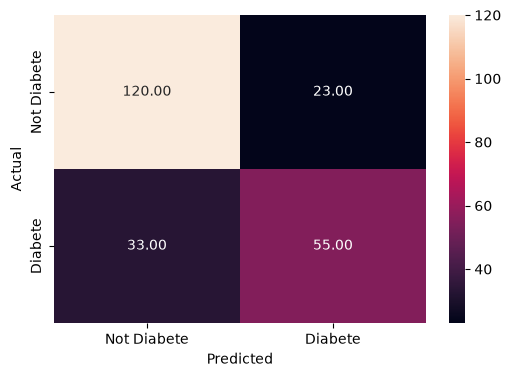

In [56]:
metrics_score(y_test, pred_test)

In [57]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X= X_train_scaled, y = y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


              precision    recall  f1-score   support

           0       0.88      0.90      0.89       357
           1       0.80      0.75      0.77       180

    accuracy                           0.85       537
   macro avg       0.84      0.83      0.83       537
weighted avg       0.85      0.85      0.85       537



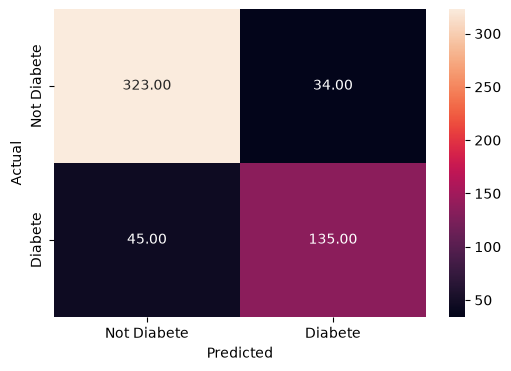

In [58]:
pred_train=knn.predict(X_train_scaled)
pred_test = knn.predict(X_test_scaled)
metrics_score(y_train, pred_train)

              precision    recall  f1-score   support

           0       0.80      0.83      0.81       143
           1       0.70      0.66      0.68        88

    accuracy                           0.76       231
   macro avg       0.75      0.74      0.74       231
weighted avg       0.76      0.76      0.76       231



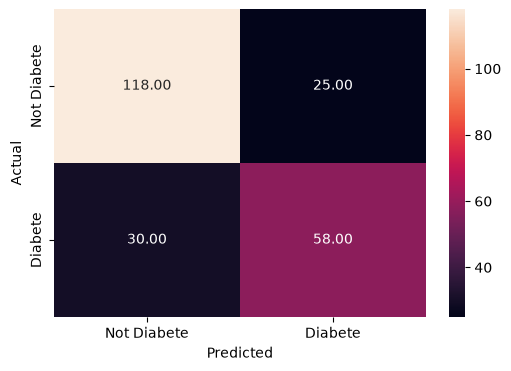

In [59]:
metrics_score(y_test, pred_test)

In [60]:
# random forest
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier( random_state = 1)

rf.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",1
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstra

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       357
           1       1.00      1.00      1.00       180

    accuracy                           1.00       537
   macro avg       1.00      1.00      1.00       537
weighted avg       1.00      1.00      1.00       537



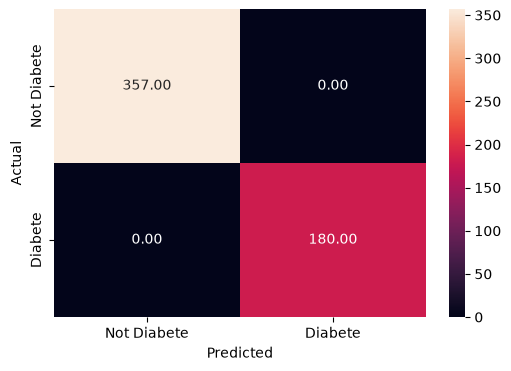

In [61]:
pred_train=rf.predict(X_train)
pred_test = rf.predict(X_test)
metrics_score(y_train, pred_train)

              precision    recall  f1-score   support

           0       0.80      0.83      0.81       143
           1       0.70      0.67      0.69        88

    accuracy                           0.77       231
   macro avg       0.75      0.75      0.75       231
weighted avg       0.76      0.77      0.77       231



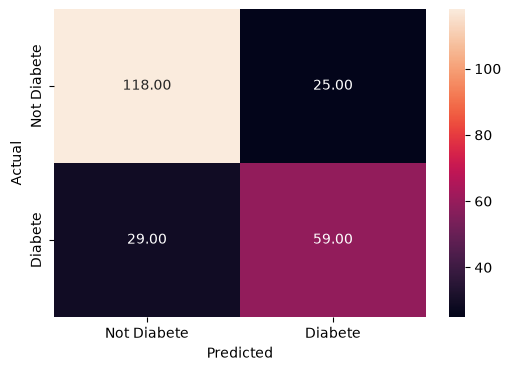

In [62]:
metrics_score(y_test, pred_test)

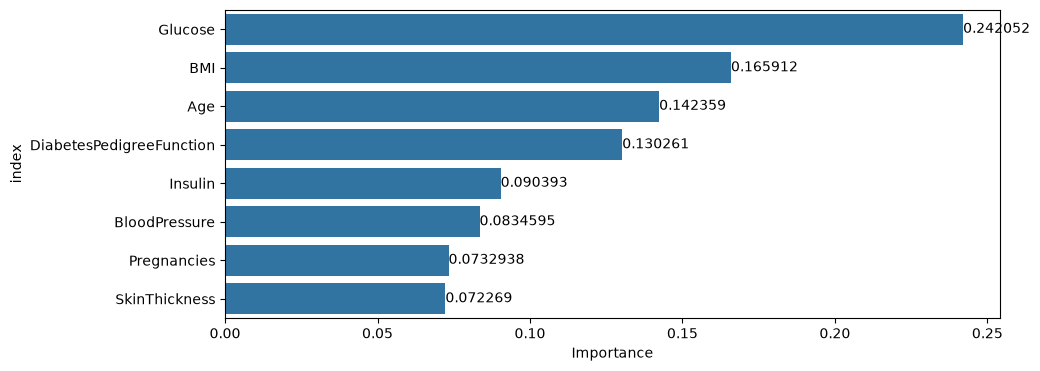

In [63]:
importances = rf.feature_importances_
columns = X.columns
importance_df = pd.DataFrame(
    importances, index = columns, 
    columns = ['Importance']).sort_values(by = 'Importance', ascending = False)
importance_df=importance_df.reset_index()
plt.figure(figsize = (10, 4))
bar =sns.barplot(data=importance_df,x='Importance', y='index', orient='h')
bar = bar.bar_label(bar.containers[0], fontsize=10)